In [1]:
import numpy as np
import astropy.io.fits as pyfits
import matplotlib.pyplot as plt
import os

Import a mass distribtution

In [2]:
with pyfits.open("mass_distributions/kappa.01.027.fits") as hdul:
    kappa = hdul[0].data
    header = hdul[0].header

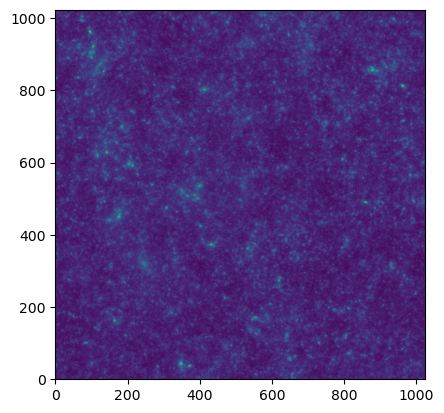

In [3]:
plt.imshow(kappa, origin='lower')
plt.show()

In [4]:
import numpy.fft as fftengine
import astropy.io.fits as pyfits

In [5]:
class Deflector(object):

    def __init__(self, filekappa, pad=False) -> None:
        kappa,header=pyfits.getdata(filekappa,header=True)
        self.kappa = kappa
        self.nx = kappa.shape[0]
        self.ny = kappa.shape[1]
        self.pad=pad
        if(pad):
            self.kpad()
        self.kx,self.ky=self.kernel()

    def kernel(self):
        """
        implement the kernel function K
        """
        x = np.linspace(-0.5,0.5, self.nx)
        y = np.linspace(-0.5,0.5, self.ny)

        kx,ky = np.meshgrid(x,y)
        norm = (kx**2 + ky**2 + 1e-12) # I think 1e-12 protects from divide by zero errors
        kx = kx/norm
        ky = ky/norm

        return kx, ky
    
    def get_deflection(self):
        kappa_ft = fftengine.rfftn(self.kappa, axes=(0,1))
        kernelx_ft = fftengine.rfftn(self.kx, axes=(0,1), s=self.kx.shape)
        kernely_ft = fftengine.rfftn(self.ky, axes=(0,1), s=self.ky.shape)

        alphax = 1.0/np.pi*fftengine.fftshift(fftengine.irfftn(kappa_ft*kernelx_ft)) 
        alphay = 1.0/np.pi*fftengine.fftshift(fftengine.irfftn(kappa_ft*kernely_ft))

        return (alphax,alphay)
    
    def get_kmap(self):
        return self.kappa
    
    def kpad(self):
        def padwithzeros(vector, pad_width, iaxis, kwargs): 
            vector[:pad_width[0]] = 0 
            vector[-pad_width[1]:] = 0 
            return vector
        
        self.kappa=np.lib.pad(self.kappa, self.kappa.shape[0], padwithzeros)

    def mapCrop(self,mappa): 
        xmin=np.int(0.5*(self.kappa.shape[0]-self.nx)) 
        ymin=np.int(0.5*(self.kappa.shape[1]-self.ny)) 
        xmax=xmin+self.nx 
        ymax=ymin+self.ny 
        mappa=mappa[xmin:xmax,ymin:ymax] 
        return(mappa)

In [6]:
df=Deflector('mass_distributions/kappa.01.017.fits') 
angx_nopad,angy_nopad=df.get_deflection() 
kappa=df.get_kmap()

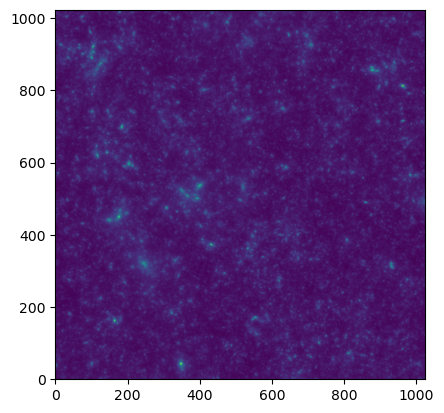

In [7]:
plt.imshow(kappa, origin='lower')
plt.show()

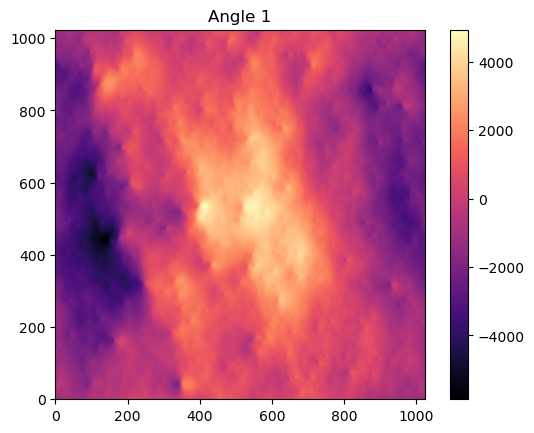

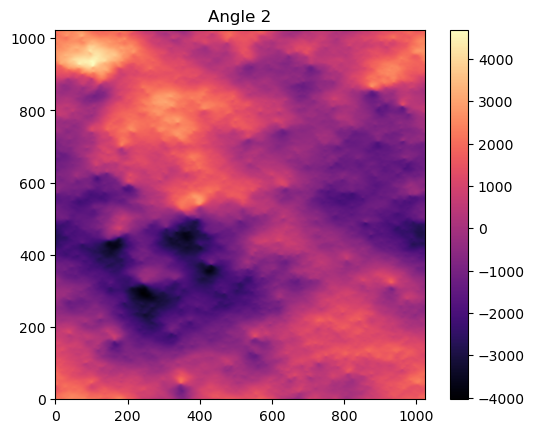

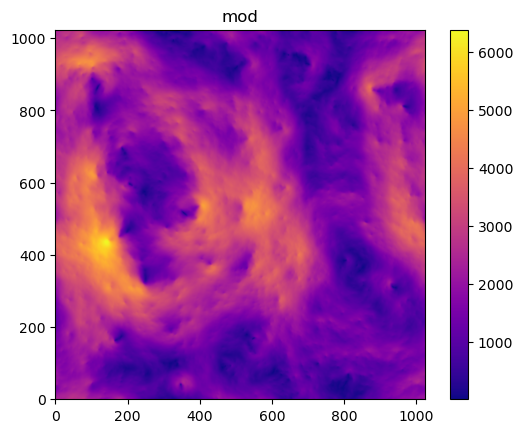

In [8]:
im = plt.imshow(angx_nopad, cmap='magma', origin='lower')
plt.colorbar(im)
plt.title("Angle 1")
plt.show()

im = plt.imshow(angy_nopad, cmap='magma', origin='lower')
plt.colorbar(im)
plt.title("Angle 2")
plt.show()

arr = np.sqrt(angx_nopad**2 + angy_nopad**2)
im = plt.imshow(arr, cmap='plasma', origin='lower')
plt.colorbar(im)
plt.title("mod")
plt.show()

In [9]:
def plot_deflection_distribution(kappafile):
    df = Deflector(kappafile)
    angx_nopad, angy_nopad = df.get_deflection()
    kappa = df.get_kmap()

    name = kappafile.split("/")[-1]


    arr = np.sqrt(angx_nopad**2 + angy_nopad**2)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

    # Left: kappa
    im0 = axes[0].imshow(kappa, cmap='grey', origin='lower')
    axes[0].set_title(r"$\kappa$ (Convergence)")
    fig.colorbar(im0, ax=axes[0])

    # Right: |alpha|
    im1 = axes[1].imshow(df.mapCrop(arr), cmap='plasma', origin='lower')
    axes[1].set_title(r"Deflection magnitude $|\alpha|$")
    fig.colorbar(im1, ax=axes[1])

    plt.tight_layout()
    plt.savefig(f"deflection_figs/{name}.png")
    plt.show()

AttributeError: module 'numpy' has no attribute 'int'.
`np.int` was a deprecated alias for the builtin `int`. To avoid this error in existing code, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

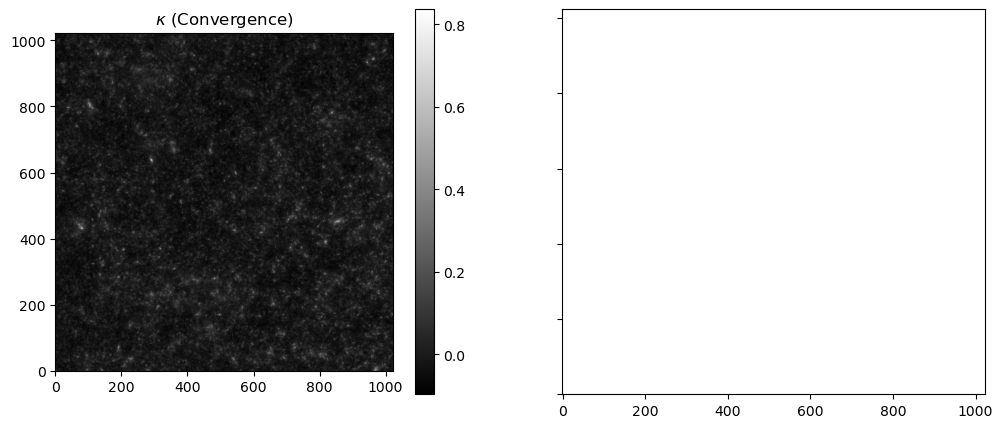

In [10]:
names = os.listdir("mass_distributions")
for kappafile in names:
    if(kappafile.split(".")[0] == "kappa"):
        plot_deflection_distribution("mass_distributions/"+kappafile)